
# QBL B-Count Dyadic Carry Investigation

Timestamp: `20260710T234301`

The notebook uses the primitive domain formulas only. It contains no file I/O and no R/S/T scheduler.
Each code cell tests one claim, emits numeric results, a figure, and an explicit PASS/FAIL result.


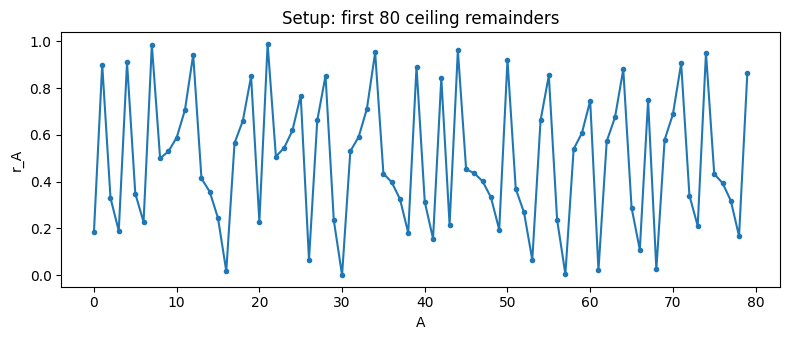

PASS: constants and A=0..10000 affine ceiling orbit initialized
lambda = 8.64252054247533887410530899753
gamma  = 8.47024460429078412793498987113


In [1]:

import mpmath as mp
import matplotlib.pyplot as plt
from collections import Counter
from sympy import isprime
MAX_A=10000
PRIME_MAX_A=1000
mp.mp.dps=3500
phi=(1+mp.sqrt(5))/2
log_phi=mp.log(phi)
lam=6*mp.log(2)/log_phi
gamma=lam+mp.mpf("1.5")-mp.log(5)/(2*log_phi)
a=(gamma-8)/2
y=2*lam-gamma
rows=[]
prevT=prevB=None
for A in range(MAX_A+1):
    T=int(mp.ceil(y)); r=mp.mpf(T)-y
    B=T if prevT is None else T-prevT
    carry=None if prevT is None else T-2*prevT
    defect=None if prevB is None else B-2*prevB
    rows.append((A,T,B,carry,defect,r))
    prevT,prevB=T,B
    y=2*y+gamma
plt.figure(figsize=(8,3.5))
plt.plot([r[0] for r in rows[:80]],[float(r[5]) for r in rows[:80]],marker='.')
plt.xlabel('A'); plt.ylabel('r_A'); plt.title('Setup: first 80 ceiling remainders')
plt.tight_layout(); plt.show()
print('PASS: constants and A=0..10000 affine ceiling orbit initialized')
print('lambda =', mp.nstr(lam,30))
print('gamma  =', mp.nstr(gamma,30))


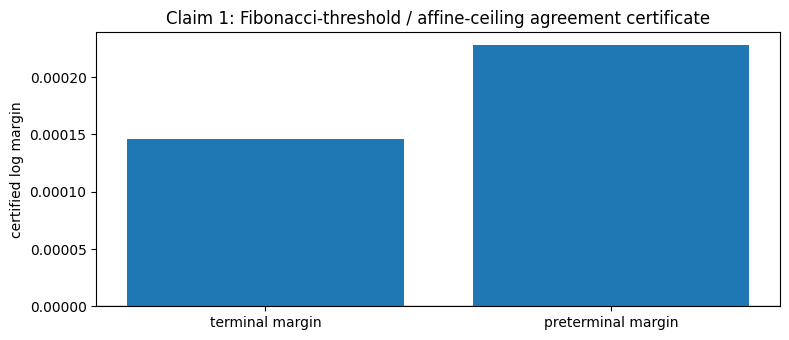

PASS: exact threshold bridge certified for A=0..10000
min r at A 1417 0.0001945773156530118927227675
min 1-r at A 1868 0.0003478207810847098521247177
certified margins 0.00014640695739990292526 0.00022780479545167957759


In [2]:

def eps(m):
    s1=-1 if (m+1)%2 else 1
    s2=-1 if (m+2)%2 else 1
    return mp.log1p(-s1*phi**(-2*m-2))+mp.log1p(-s2*phi**(-2*m-4))
minr=min((r[5],r[0]) for r in rows)
min1=min((1-r[5],r[0]) for r in rows)
right=2*log_phi*minr[0]-abs(eps(9))
left=2*log_phi*min1[0]-abs(eps(8))
passed=right>0 and left>0
plt.figure(figsize=(8,3.5))
plt.bar(['terminal margin','preterminal margin'],[float(right),float(left)])
plt.axhline(0,linewidth=1)
plt.ylabel('certified log margin')
plt.title('Claim 1: Fibonacci-threshold / affine-ceiling agreement certificate')
plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': exact threshold bridge certified for A=0..10000')
print('min r at A',minr[1],mp.nstr(minr[0],25))
print('min 1-r at A',min1[1],mp.nstr(min1[0],25))
print('certified margins',mp.nstr(right,20),mp.nstr(left,20))


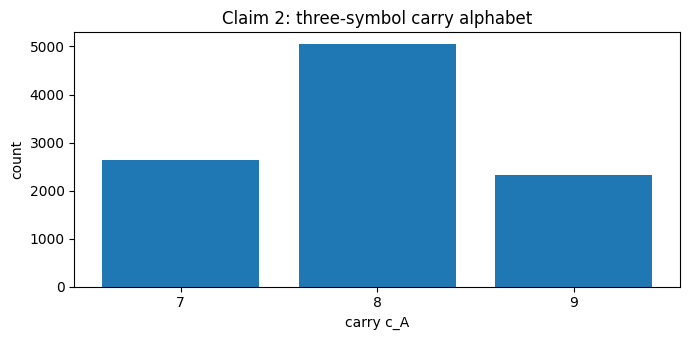

PASS: carry alphabet = [7, 8, 9]
counts = {9: 2321, 7: 2637, 8: 5042}


In [3]:

carry=Counter(r[3] for r in rows if r[3] is not None)
passed=set(carry)=={7,8,9}
plt.figure(figsize=(7,3.5))
plt.bar([str(k) for k in [7,8,9]],[carry[k] for k in [7,8,9]])
plt.xlabel('carry c_A'); plt.ylabel('count'); plt.title('Claim 2: three-symbol carry alphabet')
plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': carry alphabet =',sorted(carry))
print('counts =',dict(carry))


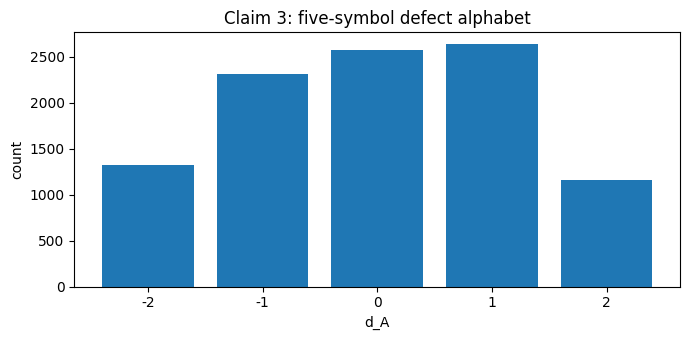

PASS: d_A = c_A-c_(A-1), alphabet = [-2, -1, 0, 1, 2]
counts = {-2: 1321, 1: 2633, 0: 2568, -1: 2315, 2: 1162}


In [4]:

defects=Counter(r[4] for r in rows[2:])
identity_ok=all(rows[A][4]==rows[A][3]-rows[A-1][3] for A in range(2,MAX_A+1))
passed=set(defects)=={-2,-1,0,1,2} and identity_ok
plt.figure(figsize=(7,3.5))
plt.bar([str(k) for k in [-2,-1,0,1,2]],[defects[k] for k in [-2,-1,0,1,2]])
plt.xlabel('d_A'); plt.ylabel('count'); plt.title('Claim 3: five-symbol defect alphabet')
plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': d_A = c_A-c_(A-1), alphabet =',sorted(defects))
print('counts =',dict(defects))


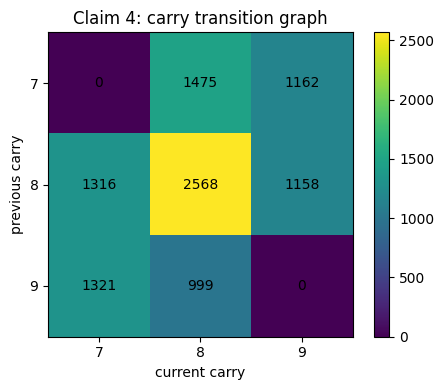

PASS: 7->7 and 9->9 are forbidden
transitions = {(9, 7): 1321, (7, 8): 1475, (8, 9): 1158, (8, 8): 2568, (8, 7): 1316, (9, 8): 999, (7, 9): 1162}


In [5]:

trans=Counter((rows[A-1][3],rows[A][3]) for A in range(2,MAX_A+1))
ks=[7,8,9]
mat=[[trans.get((i,j),0) for j in ks] for i in ks]
passed=mat[0][0]==0 and mat[2][2]==0
plt.figure(figsize=(5,4))
plt.imshow(mat)
plt.xticks(range(3),ks); plt.yticks(range(3),ks)
plt.xlabel('current carry'); plt.ylabel('previous carry'); plt.title('Claim 4: carry transition graph')
for i in range(3):
    for j in range(3): plt.text(j,i,str(mat[i][j]),ha='center',va='center')
plt.colorbar(); plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': 7->7 and 9->9 are forbidden')
print('transitions =',dict(trans))


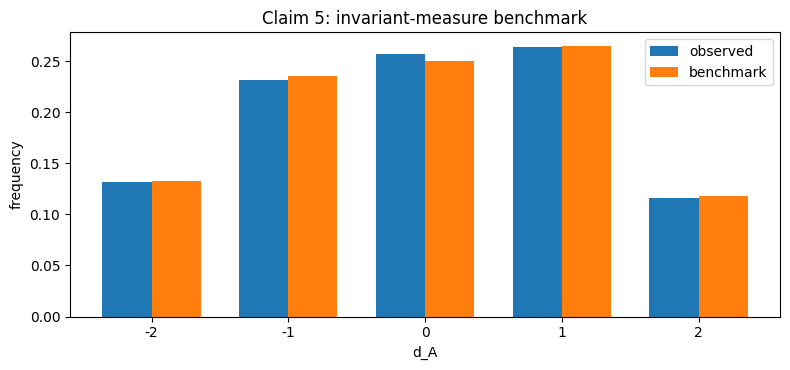

PASS: max absolute deviation < 0.01 for A=2..10000
max deviation = 0.0068256825682568256826
benchmark = {-2: 0.13243884892730398, -1: 0.23512230214539206, 0: 0.25, 1: 0.26487769785460796, 2: 0.11756115107269603}
observed  = {-2: 0.1321132113211321, -1: 0.23152315231523152, 0: 0.25682568256825683, 1: 0.2633263326332633, 2: 0.11621162116211621}


In [6]:

bench={-2:(mp.mpf('0.5')-a)/2,-1:a,0:mp.mpf('0.25'),1:mp.mpf('0.5')-a,2:a/2}
total=sum(defects.values()); emp={k:mp.mpf(defects[k])/total for k in bench}
maxdev=max(abs(emp[k]-bench[k]) for k in bench)
passed=maxdev<mp.mpf('0.01')
ks=[-2,-1,0,1,2]; x=list(range(5)); w=.36
plt.figure(figsize=(8,3.8))
plt.bar([i-w/2 for i in x],[float(emp[k]) for k in ks],width=w,label='observed')
plt.bar([i+w/2 for i in x],[float(bench[k]) for k in ks],width=w,label='benchmark')
plt.xticks(x,[str(k) for k in ks]); plt.xlabel('d_A'); plt.ylabel('frequency')
plt.title('Claim 5: invariant-measure benchmark'); plt.legend(); plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': max absolute deviation < 0.01 for A=2..10000')
print('max deviation =',mp.nstr(maxdev,20))
print('benchmark =',{k:float(bench[k]) for k in ks})
print('observed  =',{k:float(emp[k]) for k in ks})


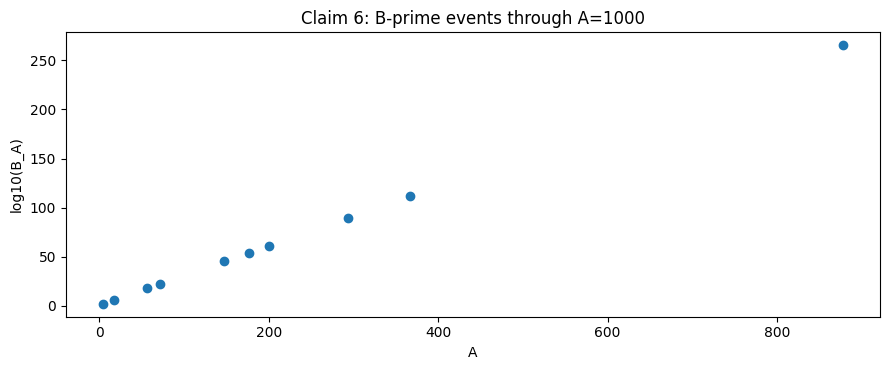

PASS: every B-prime lies on d_A=+/-1 and parity gate is exact
B-prime domains = [4, 17, 56, 72, 147, 177, 200, 294, 367, 878]
simultaneous prime domains = [17]


In [7]:

qpr=[]; bpr=[]; both=[]
for A,T,B,c,d,r in rows[:PRIME_MAX_A+1]:
    Q=6*(1<<A)-1; qp=bool(isprime(Q)); bp=bool(isprime(B))
    if qp:qpr.append(A)
    if bp:bpr.append(A)
    if qp and bp:both.append(A)
gate=all(rows[A][4] in (-1,1) for A in bpr if A>0)
parity=all((rows[A][2]%2==1)==(rows[A][4] in (-1,1)) for A in range(1,MAX_A+1))
passed=gate and parity
plt.figure(figsize=(9,3.8))
plt.scatter(bpr,[mp.log10(rows[A][2]) for A in bpr])
plt.xlabel('A'); plt.ylabel('log10(B_A)'); plt.title('Claim 6: B-prime events through A=1000')
plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': every B-prime lies on d_A=+/-1 and parity gate is exact')
print('B-prime domains =',bpr)
print('simultaneous prime domains =',both)


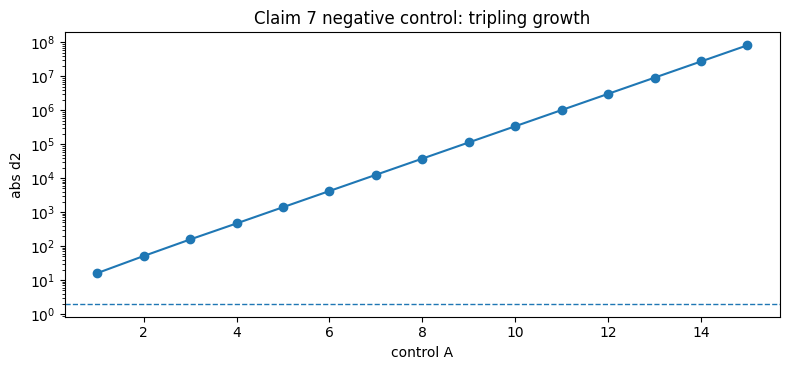

PASS: non-dyadic growth destroys the five-symbol d2 bound
control d2 = [16, 51, 157, 466, 1400, 4201, 12601, 37801, 113407, 340223, 1020663, 3061993, 9185981, 27557938, 82673815]


In [8]:

y3=3*lam-gamma; prevT=prevB=None; ctrl=[]
for A in range(16):
    T=int(mp.ceil(y3)); B=T if prevT is None else T-prevT
    d=None if prevB is None else B-2*prevB
    ctrl.append((A,B,d)); prevT,prevB=T,B; y3=3*y3+2*gamma
vals=[abs(x[2]) for x in ctrl if x[2] is not None]
passed=max(vals)>2
plt.figure(figsize=(8,3.8))
plt.plot([x[0] for x in ctrl if x[2] is not None],vals,marker='o')
plt.axhline(2,linestyle='--',linewidth=1); plt.yscale('log')
plt.xlabel('control A'); plt.ylabel('abs d2'); plt.title('Claim 7 negative control: tripling growth')
plt.tight_layout(); plt.show()
print(('PASS' if passed else 'FAIL')+': non-dyadic growth destroys the five-symbol d2 bound')
print('control d2 =',[x[2] for x in ctrl if x[2] is not None])
